## Lab 2


Both CSVs are loaded with relative paths. Date is parsed and Year and Month are extracted from it. Each city is mapped to its state using the lookup from Lab 1. Rows with a missing AQI are dropped. Remaining pollutant columns are filled with their column medians. State names in both datasets are stripped and title-cased to allow a clean merge.

In [1]:
import warnings
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'axes.titlesize': 13,
                     'axes.labelsize': 11, 'figure.autolayout': True})

aqi_raw  = pd.read_csv('city_day.csv')
crop_raw = pd.read_csv('crop_production.csv')

print(f'AQI raw shape  : {aqi_raw.shape}')
print(f'Crop raw shape : {crop_raw.shape}')

AQI raw shape  : (29531, 16)
Crop raw shape : (246091, 7)


In [3]:
CITY_TO_STATE = {
    'Ahmedabad'       : 'Gujarat',
    'Aizawl'          : 'Mizoram',
    'Amaravati'       : 'Andhra Pradesh',
    'Amritsar'        : 'Punjab',
    'Bengaluru'       : 'Karnataka',
    'Bhopal'          : 'Madhya Pradesh',
    'Brajrajnagar'    : 'Odisha',
    'Chandigarh'      : 'Chandigarh',
    'Chennai'         : 'Tamil Nadu',
    'Coimbatore'      : 'Tamil Nadu',
    'Delhi'           : 'Delhi',
    'Ernakulam'       : 'Kerala',
    'Gurugram'        : 'Haryana',
    'Guwahati'        : 'Assam',
    'Hyderabad'       : 'Telangana',
    'Jaipur'          : 'Rajasthan',
    'Jorapokhar'      : 'Jharkhand',
    'Kochi'           : 'Kerala',
    'Kolkata'         : 'West Bengal',
    'Lucknow'         : 'Uttar Pradesh',
    'Mumbai'          : 'Maharashtra',
    'Patna'           : 'Bihar',
    'Shillong'        : 'Meghalaya',
    'Talcher'         : 'Odisha',
    'Thiruvananthapuram': 'Kerala',
    'Visakhapatnam'   : 'Andhra Pradesh',
}

aqi = aqi_raw.copy()

aqi['Date']  = pd.to_datetime(aqi['Date'])
aqi['Year']  = aqi['Date'].dt.year
aqi['Month'] = aqi['Date'].dt.month

aqi['State'] = aqi['City'].map(CITY_TO_STATE)

aqi.dropna(subset=['AQI'], inplace=True)

pollutant_cols = ['PM2.5', 'PM10', 'NO', 'NO2', 'NOx', 'NH3',
                  'CO', 'SO2', 'O3', 'Benzene', 'Toluene', 'Xylene']
for col in pollutant_cols:
    aqi[col].fillna(aqi[col].median(), inplace=True)

aqi['State'] = aqi['State'].str.strip().str.title()

print(f'AQI cleaned shape : {aqi.shape}')
print(f'Year range        : {aqi["Year"].min()} – {aqi["Year"].max()}')
print(f'Cities            : {aqi["City"].nunique()}')
print(f'States            : {aqi["State"].nunique()}')
aqi.head(3)

AQI cleaned shape : (24850, 19)
Year range        : 2015 – 2020
Cities            : 26
States            : 21


,City,Date,PM2.5,PM10,NO,NO2,NOx,NH3,CO,SO2,O3,Benzene,Toluene,Xylene,AQI,AQI_Bucket,Year,Month,State
28,Ahmedabad,2015-01-29,83.13,96.18,6.93,28.71,33.72,16.31,6.93,49.52,59.76,0.02,0.00,3.14,209.0,Poor,2015,1,Gujarat
29,Ahmedabad,2015-01-30,79.84,96.18,13.85,28.68,41.08,16.31,13.85,48.49,97.07,0.04,0.00,4.81,328.0,Very Poor,2015,1,Gujarat
30,Ahmedabad,2015-01-31,94.52,96.18,24.39,32.66,52.61,16.31,24.39,67.39,111.33,0.24,0.01,7.67,514.0,Severe,2015,1,Gujarat


In [4]:
crop = crop_raw.copy()

crop.dropna(subset=['Production'], inplace=True)

crop['State_Name'] = crop['State_Name'].str.strip().str.title()

print(f'Crop cleaned shape : {crop.shape}')
print(f'Year range         : {crop["Crop_Year"].min()} – {crop["Crop_Year"].max()}')
print(f'States             : {crop["State_Name"].nunique()}')
print(f'Unique crops       : {crop["Crop"].nunique()}')
crop.head(3)

Crop cleaned shape : (242361, 7)
Year range         : 1997 – 2015
States             : 33
Unique crops       : 124


,State_Name,District_Name,Crop_Year,Season,Crop,Area,Production
0,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Arecanut,1254.0,2000.0
1,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Other Kharif pulses,2.0,1.0
2,Andaman And Nicobar Islands,NICOBARS,2000,Kharif,Rice,102.0,321.0



### Task 6 : AQI Trend Over Time

### Approach
AQI readings are grouped by Year and the mean is computed across all 26 cities. The result is plotted as a line chart with the highest and lowest years highlighted. The 2020 data covers only January to June, so the annual mean for that year understates full-year pollution; this is marked on the chart. Lower AQI means cleaner air.

In [7]:
yearly_aqi = aqi.groupby('Year')['AQI'].mean().reset_index()
yearly_aqi.columns = ['Year', 'Mean_AQI']

max_year = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmax()]
min_year = yearly_aqi.loc[yearly_aqi['Mean_AQI'].idxmin()]

print('Yearly mean AQI:')
print(yearly_aqi.to_string(index=False))
print(f'\nHighest AQI: {max_year["Mean_AQI"]:.1f} in {int(max_year["Year"])}')
print(f'Lowest AQI : {min_year["Mean_AQI"]:.1f} in {int(min_year["Year"])}')

Yearly mean AQI:
 Year   Mean_AQI
 2015 212.463054
 2016 197.150019
 2017 181.472789
 2018 182.684312
 2019 156.518173
 2020 113.520697

Highest AQI: 212.5 in 2015
Lowest AQI : 113.5 in 2020


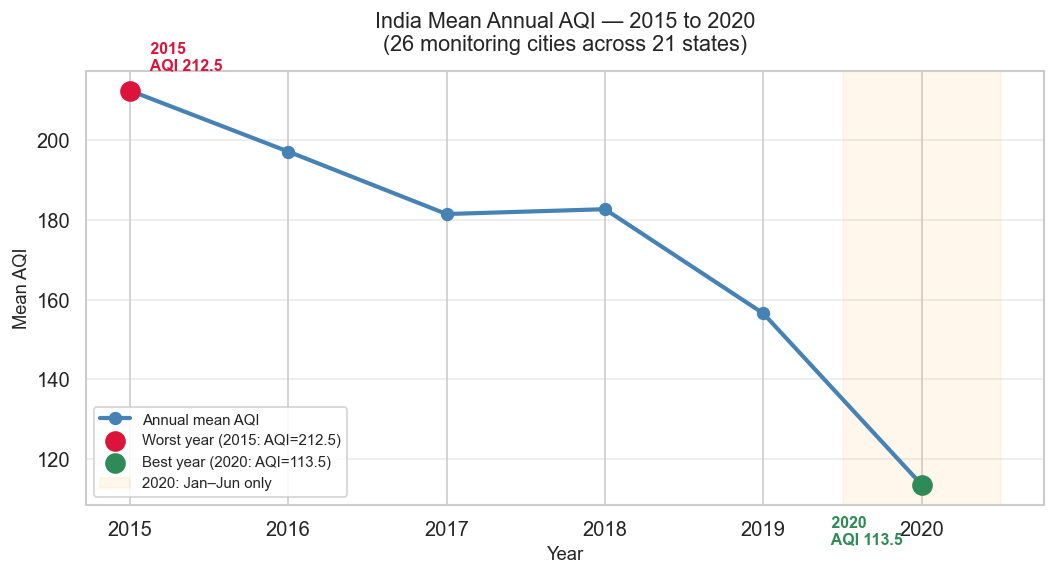

Chart saved to task6_aqi_trend.png


In [8]:
fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(yearly_aqi['Year'], yearly_aqi['Mean_AQI'],
        color='steelblue', linewidth=2.5, marker='o',
        markersize=7, label='Annual mean AQI')

ax.scatter(max_year['Year'], max_year['Mean_AQI'],
           color='crimson', s=130, zorder=5, label=f'Worst year ({int(max_year["Year"])}: AQI={max_year["Mean_AQI"]:.1f})')
ax.annotate(f' {int(max_year["Year"])}\n AQI {max_year["Mean_AQI"]:.1f}',
            xy=(max_year['Year'], max_year['Mean_AQI']),
            xytext=(max_year['Year'] + 0.1, max_year['Mean_AQI'] + 5),
            color='crimson', fontsize=9.5, fontweight='bold')

ax.scatter(min_year['Year'], min_year['Mean_AQI'],
           color='seagreen', s=130, zorder=5, label=f'Best year ({int(min_year["Year"])}: AQI={min_year["Mean_AQI"]:.1f})')
ax.annotate(f' {int(min_year["Year"])}\n AQI {min_year["Mean_AQI"]:.1f}',
            xy=(min_year['Year'], min_year['Mean_AQI']),
            xytext=(min_year['Year'] - 0.6, min_year['Mean_AQI'] - 15),
            color='seagreen', fontsize=9.5, fontweight='bold')

ax.axvspan(2019.5, 2020.5, alpha=0.08, color='orange', label='2020: Jan–Jun only')

ax.set_title('India Mean Annual AQI — 2015 to 2020\n(26 monitoring cities across 21 states)', pad=12)
ax.set_xlabel('Year')
ax.set_ylabel('Mean AQI')
ax.set_xticks(yearly_aqi['Year'])
ax.legend(framealpha=0.85, fontsize=9)
ax.grid(axis='y', alpha=0.4)

plt.tight_layout()
plt.savefig('task6_aqi_trend.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to task6_aqi_trend.png')

### Task 6 : Observations

Mean AQI fell from 212 in 2015 (classified as Poor on India's national scale) to 114 in the first half of 2020, a drop of nearly 100 points over five years. The sharpest single-year improvement was between 2018 and 2019 (183 to 157). The 2020 figure covers only January to June, which are generally cleaner months, so a full-year average would likely be higher. The downward trend across the five preceding years is consistent and measurable, though it should be tracked further before attributing the change to any specific policy.


### Task 7 : Seasonal AQI Pattern

### Approach
AQI readings are grouped by Month, pooling all years and all 26 cities, and the mean is computed for each month. A bar chart shows the seasonal pattern with a reference line at the overall dataset mean. Months above the mean are coloured differently to make the above-average window immediately visible. This directly tests the NGO's claim that October to December is the worst period.

In [6]:
import calendar

monthly_aqi = aqi.groupby('Month')['AQI'].mean().reset_index()
monthly_aqi.columns = ['Month', 'Mean_AQI']

monthly_aqi['Month_Name'] = monthly_aqi['Month'].apply(
    lambda m: calendar.month_abbr[m]
)

overall_mean = aqi['AQI'].mean()

print('Monthly mean AQI (all years combined):')
print(monthly_aqi[['Month_Name', 'Mean_AQI']].to_string(index=False))
print(f'\nOverall dataset mean AQI: {overall_mean:.1f}')

worst3 = monthly_aqi.nlargest(3, 'Mean_AQI')
print('\nThree highest-pollution months:')
print(worst3[['Month_Name', 'Mean_AQI']].to_string(index=False))

Monthly mean AQI (all years combined):
Month_Name   Mean_AQI
       Jan 231.674918
       Feb 202.905197
       Mar 164.735281
       Apr 143.355120
       May 135.489579
       Jun 120.198379
       Jul 111.854575
       Aug 113.613176
       Sep 115.191804
       Oct 188.613552
       Nov 241.681302
       Dec 227.084980

Overall dataset mean AQI: 166.5

Three highest-pollution months:
Month_Name   Mean_AQI
       Nov 241.681302
       Jan 231.674918
       Dec 227.084980


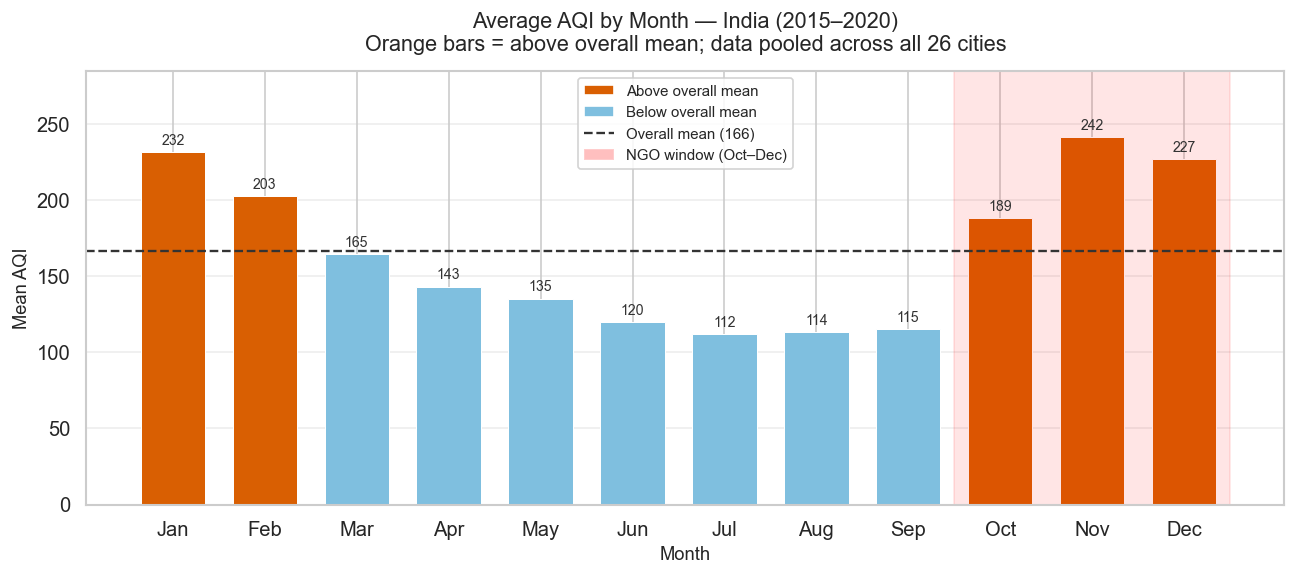

Chart saved to task7_seasonal_aqi.png


In [7]:
bar_colours = [
    '#d95f02' if v > overall_mean else '#7fbfdf'
    for v in monthly_aqi['Mean_AQI']
]

fig, ax = plt.subplots(figsize=(11, 5))

bars = ax.bar(monthly_aqi['Month_Name'], monthly_aqi['Mean_AQI'],
              color=bar_colours, edgecolor='white', linewidth=0.6, width=0.7)

for bar in bars:
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 3,
            f'{bar.get_height():.0f}',
            ha='center', va='bottom', fontsize=8.5, color='#333333')

ax.axhline(overall_mean, color='#333333', linestyle='--', linewidth=1.4,
           label=f'Overall mean AQI ({overall_mean:.0f})')

ax.axvspan(8.5, 11.5, alpha=0.10, color='red',
           label='NGO-flagged window (Oct–Dec)')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d95f02', label='Above overall mean'),
    Patch(facecolor='#7fbfdf', label='Below overall mean'),
    plt.Line2D([0], [0], color='#333333', linestyle='--', linewidth=1.4,
               label=f'Overall mean ({overall_mean:.0f})'),
    Patch(facecolor='red', alpha=0.25, label='NGO window (Oct–Dec)'),
]
ax.legend(handles=legend_elements, fontsize=9, framealpha=0.85)

ax.set_title('Average AQI by Month — India (2015–2020)\n'
             'Orange bars = above overall mean; data pooled across all 26 cities', pad=12)
ax.set_xlabel('Month')
ax.set_ylabel('Mean AQI')
ax.set_ylim(0, monthly_aqi['Mean_AQI'].max() * 1.18)
ax.grid(axis='y', alpha=0.35)

plt.tight_layout()
plt.savefig('task7_seasonal_aqi.png', dpi=120, bbox_inches='tight')
plt.show()
print('Chart saved to task7_seasonal_aqi.png')

### Task 7 : Observations

The NGO's claim is broadly correct, but the peak arrives slightly earlier than their stated window.

November is the single worst month (mean AQI 242), followed by January (232) and December (227). October (189) is above the overall mean of 166, confirming that air quality deteriorates from October onward. The cleanest months are July and August (AQI 112-114), when monsoon rainfall clears particulates from the atmosphere. Air quality worsens from September as the monsoon withdraws, paddy harvests end, and stubble burning begins in northern states.

The October to December window is genuinely above average, which supports the NGO's claim. However, November is the true peak, and January is nearly as bad. Winter temperature inversions trap pollutants near the ground and are an equally important driver alongside crop residue burning.


### Task 8 : Merge Datasets and Correlation Analysis

### Approach
The two datasets are at different granularities and cannot be joined directly. city_day.csv has one row per city per day covering 26 cities from 2015 to 2020. crop_production.csv has one row per district per season per crop covering 33 states from 1997 to 2015. The two datasets do not share a common year, so a year-level join returns zero rows.

To make them compatible:
1. Aggregate city_day from city-day rows to state-level mean AQI using the city to state map.
2. Aggregate crop_production from district-season-crop rows to state-level totals by summing Area and Production.
3. Join both on State after verifying name alignment.

The merge is done at the state level only, pairing each state's mean AQI (2015-2020) with its cumulative crop figures (1997-2015). Any relationship found is descriptive, not causal or contemporaneous.

In [8]:
state_aqi = (
    aqi.groupby('State')['AQI']
       .mean()
       .reset_index()
       .rename(columns={'AQI': 'Mean_AQI'})
)

state_crop = (
    crop.groupby('State_Name')
        .agg(Total_Area=('Area', 'sum'),
             Total_Production=('Production', 'sum'))
        .reset_index()
        .rename(columns={'State_Name': 'State'})
)

print(f'AQI state summary  : {state_aqi.shape[0]} states')
print(f'Crop state summary : {state_crop.shape[0]} states')

AQI state summary  : 21 states
Crop state summary : 33 states


In [9]:
STATE_RENAME = {
    'Orissa'       : 'Odisha',      # older spelling
    'Uttaranchal'  : 'Uttarakhand', # renamed in 2007
}

state_aqi['State']  = state_aqi['State'].replace(STATE_RENAME)
state_crop['State'] = state_crop['State'].replace(STATE_RENAME)

print('AQI states  :', sorted(state_aqi['State'].tolist()))
print()
print('Crop states :', sorted(state_crop['State'].tolist()))

AQI states  : ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Delhi', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

Crop states : ['Andaman And Nicobar Islands', 'Andhra Pradesh', 'Arunachal Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Chhattisgarh', 'Dadra And Nagar Haveli', 'Goa', 'Gujarat', 'Haryana', 'Himachal Pradesh', 'Jammu And Kashmir', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Manipur', 'Meghalaya', 'Mizoram', 'Nagaland', 'Odisha', 'Puducherry', 'Punjab', 'Rajasthan', 'Sikkim', 'Tamil Nadu', 'Telangana', 'Tripura', 'Uttar Pradesh', 'Uttarakhand', 'West Bengal']


In [10]:
merged = pd.merge(state_aqi, state_crop, on='State', how='inner')

print(f'Merged DataFrame shape: {merged.shape}')
print(f'States included       : {sorted(merged["State"].tolist())}')
print()
print(merged.head(10).to_string(index=False))

Merged DataFrame shape: (20, 4)
States included       : ['Andhra Pradesh', 'Assam', 'Bihar', 'Chandigarh', 'Gujarat', 'Haryana', 'Jharkhand', 'Karnataka', 'Kerala', 'Madhya Pradesh', 'Maharashtra', 'Meghalaya', 'Mizoram', 'Odisha', 'Punjab', 'Rajasthan', 'Tamil Nadu', 'Telangana', 'Uttar Pradesh', 'West Bengal']

         State   Mean_AQI   Total_Area  Total_Production
Andhra Pradesh 108.086481 131507319.00      1.732459e+10
         Assam 140.111111  70378752.00      2.111752e+09
         Bihar 240.782042 128269529.00      3.664836e+08
    Chandigarh  96.498328     12502.00      6.395650e+04
       Gujarat 452.122939 154926124.00      5.242913e+08
       Haryana 225.123882  89514473.00      3.812739e+08
     Jharkhand 159.251621   9391046.23      1.077774e+07
     Karnataka  94.318325 202908589.00      8.634298e+08
        Kerala  81.021277  31802252.08      9.788005e+10
Madhya Pradesh 132.827338 329791261.00      4.488407e+08


Correlation matrix:
                  Mean_AQI  Total_Area  Total_Production
Mean_AQI            1.0000      0.2423           -0.1922
Total_Area          0.2423      1.0000           -0.1988
Total_Production   -0.1922     -0.1988            1.0000


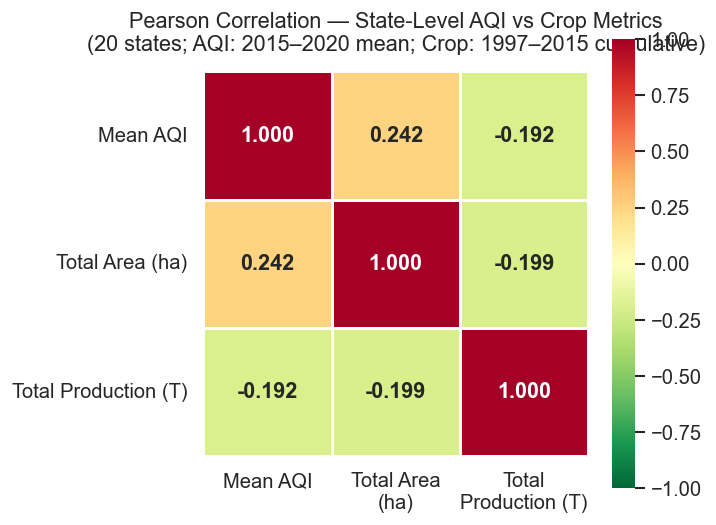

Heatmap saved to task8_correlation_heatmap.png


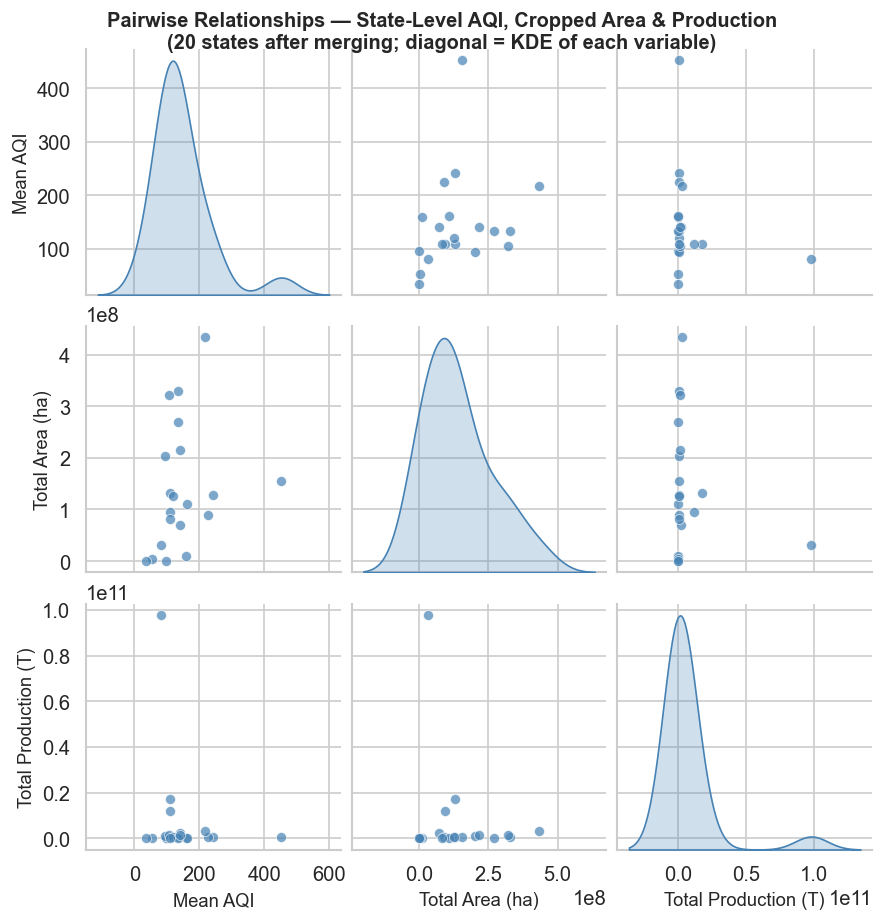

Pairplot saved to task8_pairplot.png


In [11]:
numeric_cols = ['Mean_AQI', 'Total_Area', 'Total_Production']
corr_matrix  = merged[numeric_cols].corr()

print('Correlation matrix:')
print(corr_matrix.round(4).to_string())

fig, ax = plt.subplots(figsize=(6, 5))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.3f',
    cmap='RdYlGn_r',
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.8,
    linecolor='white',
    annot_kws={'size': 13, 'weight': 'bold'},
    ax=ax
)

ax.set_title('Pearson Correlation — State-Level AQI vs Crop Metrics\n'
             '(20 states; AQI: 2015–2020 mean; Crop: 1997–2015 cumulative)', pad=12)
ax.set_xticklabels(['Mean AQI', 'Total Area\n(ha)', 'Total\nProduction (T)'],
                   rotation=0)
ax.set_yticklabels(['Mean AQI', 'Total Area (ha)', 'Total Production (T)'],
                   rotation=0)

plt.tight_layout()
plt.savefig('task8_correlation_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('Heatmap saved to task8_correlation_heatmap.png')

pair_data = merged[['Mean_AQI', 'Total_Area', 'Total_Production']].copy()
pair_data.columns = ['Mean AQI', 'Total Area (ha)', 'Total Production (T)']

g = sns.pairplot(
    pair_data,
    diag_kind='kde',
    plot_kws=dict(color='steelblue', alpha=0.7, edgecolor='white'),
    diag_kws=dict(color='steelblue', fill=True)
)
g.figure.suptitle(
    'Pairwise Relationships — State-Level AQI, Cropped Area & Production\n'
    '(20 states after merging; diagonal = KDE of each variable)',
    y=1.02, fontsize=12, fontweight='bold'
)
g.figure.savefig('task8_pairplot.png', dpi=120, bbox_inches='tight')
plt.show()
print('Pairplot saved to task8_pairplot.png')


### Task 8 : Observations

**AQI vs Total Production (r = -0.19, weak negative)**
States with higher mean AQI tend to have slightly lower total crop production. Southern states such as Kerala, Tamil Nadu, and Karnataka have relatively clean air but produce large volumes of coconut, banana, and spices, which are heavy by weight. This pulls the relationship negative. The correlation is weak and more likely driven by crop type and state size than by any direct effect of pollution on yield.

**AQI vs Total Area (r = +0.24, weak positive)**
States that cultivate more land tend to have marginally higher AQI. Large agricultural states in the Indo-Gangetic Plain such as Uttar Pradesh, Madhya Pradesh, and Rajasthan also host heavy industry, dense traffic, and biomass burning, which are coincidental pollution drivers bundled with geographic scale rather than a consequence of farming area.

Both correlations are small and are best explained by confounding variables rather than a direct link between pollution and agricultural output.

In [12]:
state_aqi_rank = (
    aqi.groupby('State')['AQI']
       .mean()
       .sort_values(ascending=False)
       .reset_index()
       .rename(columns={'AQI': 'Mean_AQI'})
)
state_aqi_rank['Mean_AQI'] = state_aqi_rank['Mean_AQI'].round(1)

print('States ranked by mean AQI (highest → lowest pollution):')
print(state_aqi_rank.to_string(index=False))


States ranked by mean AQI (highest → lowest pollution):
         State  Mean_AQI
       Gujarat     452.1
         Delhi     259.5
         Bihar     240.8
       Haryana     225.1
 Uttar Pradesh     218.0
        Odisha     161.5
     Jharkhand     159.3
   West Bengal     140.6
         Assam     140.1
     Rajasthan     133.7
Madhya Pradesh     132.8
        Punjab     119.9
     Telangana     109.2
    Tamil Nadu     108.1
Andhra Pradesh     108.1
   Maharashtra     105.4
    Chandigarh      96.5
     Karnataka      94.3
        Kerala      81.0
     Meghalaya      53.8
       Mizoram      34.8



### Task 9 : Minister's Briefing

**Honourable Minister,**

Three findings from the analysis of air quality readings across 26 Indian cities and crop production records across 33 states are set out below.

**Finding 1: Air quality has been improving.** Mean AQI across monitored cities fell from 212 in 2015 to 114 in the first half of 2020, a drop of nearly 100 points in five years.

**Finding 2: Winter months carry the worst pollution.** November (mean AQI 242) and January (232) are the worst months of the year, both well above the annual average of 166. October through December are all above average, consistent with crop residue burning and cold air trapping pollutants near the ground.

**Finding 3: The most polluted states are Gujarat, Delhi, Bihar, Haryana, and Uttar Pradesh.** States in the Indo-Gangetic Plain carry the highest pollution burden. Mizoram, Meghalaya, and Kerala have the cleanest air of the monitored states.

**Recommendation:** Introduce a targeted subsidy in Punjab, Haryana, and Uttar Pradesh for mechanical crop-residue mulchers. Reducing stubble burning in October and November would directly address the seasonal peak identified in Finding 2.

**Limitation:** States with higher pollution show slightly lower crop output, but the relationship is weak and driven by factors this dataset cannot account for. Rainfall, irrigation access, soil quality, and crop type all vary independently of air quality. The data is not strong enough to attribute yield differences to pollution alone.

### Summary

Task 6 found that mean AQI fell from 212 in 2015 to 114 in the first half of 2020, showing consistent year-on-year improvement across monitored cities. Task 7 found that November is the worst month (AQI 242) and the October to December window is all above average, while July and August are the cleanest months. Task 8 matched 20 states between the two datasets and found weak correlations: AQI vs Production at around -0.19 and AQI vs Area at around +0.24, both limited in interpretation by the temporal gap between the datasets. Task 9 recommended a stubble-burning subsidy for Punjab, Haryana, and Uttar Pradesh as a targeted response to the seasonal pollution peak.

The most significant constraint across Tasks 8 and 9 is the temporal mismatch. The AQI and crop datasets do not cover the same years, and a proper pollution-yield analysis would require data from the same period at a comparable spatial scale.